In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
import joblib

In [4]:
DATA = '../dataset/maintenance_records.csv'

In [5]:
df = pd.read_csv(DATA)
display(df.head())
display(df.describe())
display(df.info())

print(f'Number of missing values\n{"="*20}\n', df.isnull().sum())
print(f'Number of duplicate values\n{"="*20}\n', df.duplicated().sum())
df.drop_duplicates(inplace=True)

df.set_index('maintenance_id', inplace=True)

,maintenance_id,truck_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description
0,MAINT00000001,TRK00085,2022-01-01,Inspection,400255,7.8,781.42,10.41,791.83,Kansas City,22.2,Emergency Inspection
1,MAINT00000002,TRK00041,2022-01-01,Tire,268041,0.9,80.91,3207.16,3288.07,Seattle,8.0,Scheduled Tire
2,MAINT00000003,TRK00090,2022-01-01,Preventive,698915,7.2,733.18,1570.57,2303.75,Miami,16.5,Routine Preventive
3,MAINT00000004,TRK00056,2022-01-02,Inspection,416522,2.8,298.80,67.48,366.28,Kansas City,34.6,Emergency Inspection
4,MAINT00000005,TRK00029,2022-01-02,Repair,179968,4.6,409.08,982.59,1391.67,Omaha,4.4,Emergency Repair


,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,downtime_hours
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000
mean,401534.787671,4.178459,438.529825,1523.995271,1962.525096,24.736473
std,207093.951665,2.131282,229.989621,1103.739471,1135.418952,13.312263
min,50156.000000,0.500000,43.280000,0.140000,60.820000,2.000000
25%,215376.500000,2.300000,242.600000,443.125000,906.752500,13.300000
50%,407955.000000,4.200000,435.200000,1465.415000,1896.045000,24.750000
75%,585079.000000,6.000000,622.382500,2489.445000,2938.257500,36.225000
max,749875.000000,8.000000,976.870000,3498.610000,4426.570000,48.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   maintenance_id       2920 non-null   object 
 1   truck_id             2920 non-null   object 
 2   maintenance_date     2920 non-null   object 
 3   maintenance_type     2920 non-null   object 
 4   odometer_reading     2920 non-null   int64  
 5   labor_hours          2920 non-null   float64
 6   labor_cost           2920 non-null   float64
 7   parts_cost           2920 non-null   float64
 8   total_cost           2920 non-null   float64
 9   facility_location    2920 non-null   object 
 10  downtime_hours       2920 non-null   float64
 11  service_description  2920 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 273.9+ KB


None

Number of missing values
 maintenance_id         0
truck_id               0
maintenance_date       0
maintenance_type       0
odometer_reading       0
labor_hours            0
labor_cost             0
parts_cost             0
total_cost             0
facility_location      0
downtime_hours         0
service_description    0
dtype: int64
Number of duplicate values
 0


In [ ]:
print(df.columns.str.strip())

Index(['truck_id', 'maintenance_date', 'maintenance_type', 'odometer_reading',
       'labor_hours', 'labor_cost', 'parts_cost', 'total_cost',
       'facility_location', 'downtime_hours', 'service_description'],
      dtype='object')


In [ ]:
# split service_description into 2 columns
df[['service_detail', 'service_type']] = df['service_description'].str.split(' ', expand=True)
df.drop(columns=['service_description'], inplace=True)
df[['service_type', 'service_detail']] .head()

,service_type,service_detail
maintenance_id,,
MAINT00000001,Inspection,Emergency
MAINT00000002,Tire,Scheduled
MAINT00000003,Preventive,Routine
MAINT00000004,Inspection,Emergency
MAINT00000005,Repair,Emergency


In [ ]:
summary = df.describe(include='object')
display(summary)

categorical_cols = df.select_dtypes(include='object').columns

maintenance_information = ['maintenance_type','service_detail','facility_location']
for col in maintenance_information:
    print(f'\n{col}\n{"="*20}\n', df[col].unique())
# I can split the service_description into 2 columns, which are service_type and service_detail. 

,truck_id,maintenance_date,maintenance_type,facility_location,service_detail,service_type
count,2920,2920,2920,2920,2920,2920
unique,120,1020,7,25,3,7
top,TRK00003,2023-10-25,Inspection,Los Angeles,Scheduled,Inspection
freq,41,9,432,139,1004,432



maintenance_type
 ['Inspection' 'Tire' 'Preventive' 'Repair' 'Transmission' 'Brake' 'Engine']

service_detail
 ['Emergency' 'Scheduled' 'Routine']

facility_location
 ['Kansas City' 'Seattle' 'Miami' 'Omaha' 'Denver' 'Dallas' 'Columbus'
 'Atlanta' 'Nashville' 'Philadelphia' 'Las Vegas' 'New York' 'Detroit'
 'Charlotte' 'Minneapolis' 'Phoenix' 'Portland' 'Los Angeles' 'Milwaukee'
 'Salt Lake City' 'Chicago' 'Indianapolis' 'Oklahoma City' 'Memphis'
 'Houston']


In [ ]:
is_identical = df['maintenance_type'] == df['service_type']
print('Is maintenance_type identical to service_type?', is_identical.all())

if is_identical.all():
    drop_cols = ['service_type']
    df.drop(columns=drop_cols, inplace=True)
    

Is maintenance_type identical to service_type? True


days between service interval 

In [ ]:
df['maintenance_date'] = pd.to_datetime(df['maintenance_date'])
df = df.sort_values(by=['truck_id', 'maintenance_date'])
df['days_since_last'] = df.groupby('truck_id')['maintenance_date'].diff().dt.days
df['days_since_last'] = df['days_since_last'].fillna(0)
df.head()


,truck_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_detail,days_since_last
maintenance_id,,,,,,,,,,,,
MAINT00000059,TRK00001,2022-01-21,Tire,745241,5.2,489.56,2142.69,2632.25,Oklahoma City,20.7,Routine,0.0
MAINT00000081,TRK00001,2022-01-29,Brake,290198,2.5,220.30,1528.43,1748.73,Atlanta,42.4,Routine,8.0
MAINT00000244,TRK00001,2022-04-04,Inspection,338237,2.5,286.79,4.55,291.34,Phoenix,27.5,Routine,65.0
MAINT00000255,TRK00001,2022-04-07,Brake,609138,0.6,55.46,3201.35,3256.81,Phoenix,44.3,Routine,3.0
MAINT00000366,TRK00001,2022-05-13,Preventive,59181,5.4,580.05,1389.37,1969.42,Columbus,43.9,Routine,36.0


## graph

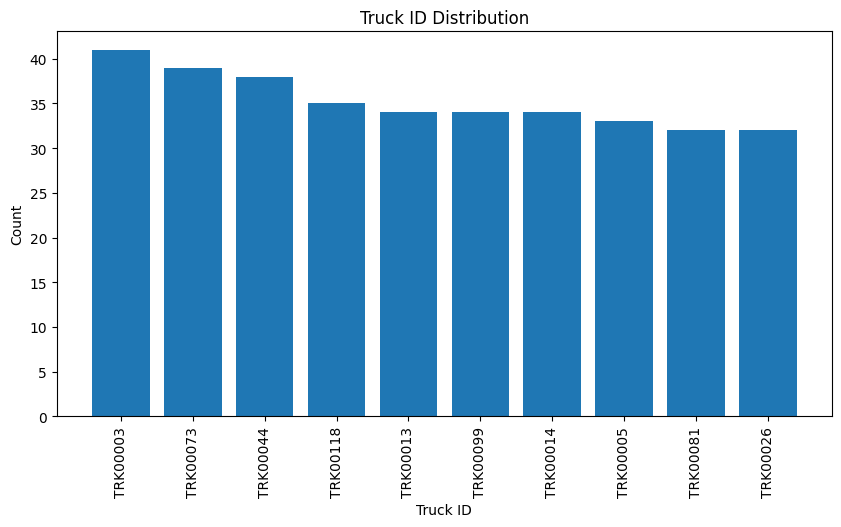

In [ ]:
plt.figure(figsize=(10,5))
plt.title('Truck ID Distribution')
plt.xlabel('Truck ID')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.bar(df['truck_id'].value_counts().head(10).index, df['truck_id'].value_counts().head(10).values)
plt.show()

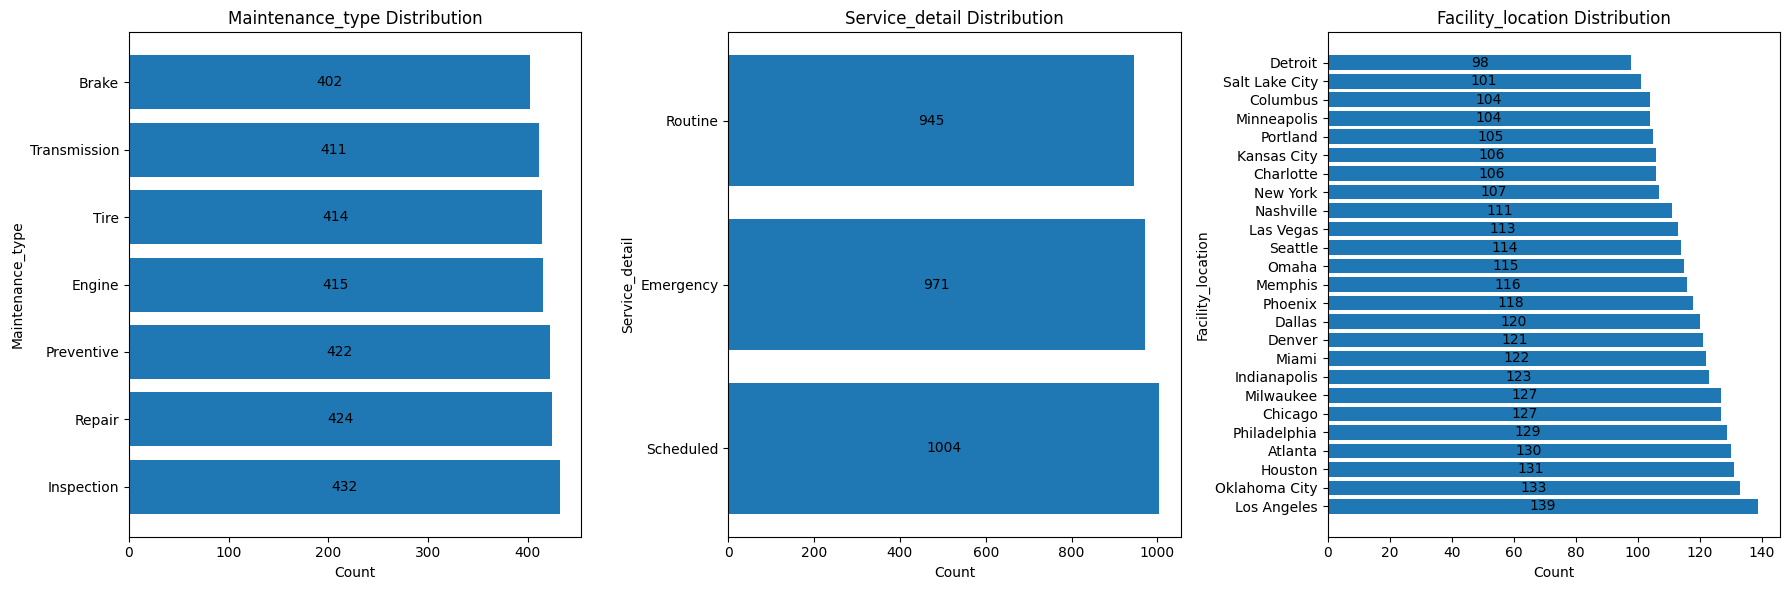

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(maintenance_information), figsize=(18, 6))

for ax, col in zip(axes, maintenance_information):
    counts = df[col].value_counts()
    hbars = ax.barh(counts.index, counts.values)
    ax.set_title(f'{col.capitalize()} Distribution')
    ax.set_xlabel('Count')
    ax.set_ylabel(col.capitalize())
    ax.bar_label(hbars, label_type='center')

plt.tight_layout()
plt.show()


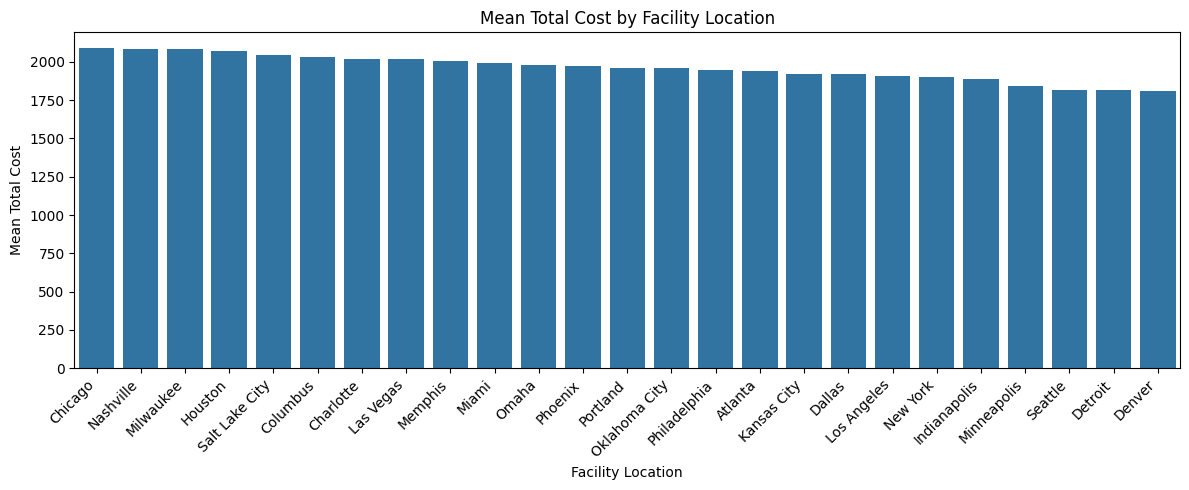

In [ ]:
mean_total_cost_by_location = (
    df.groupby('facility_location', as_index=False)['total_cost']
      .mean()
      .sort_values('total_cost', ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=mean_total_cost_by_location, x='facility_location', y='total_cost')
plt.title('Mean Total Cost by Facility Location')
plt.xlabel('Facility Location')
plt.ylabel('Mean Total Cost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

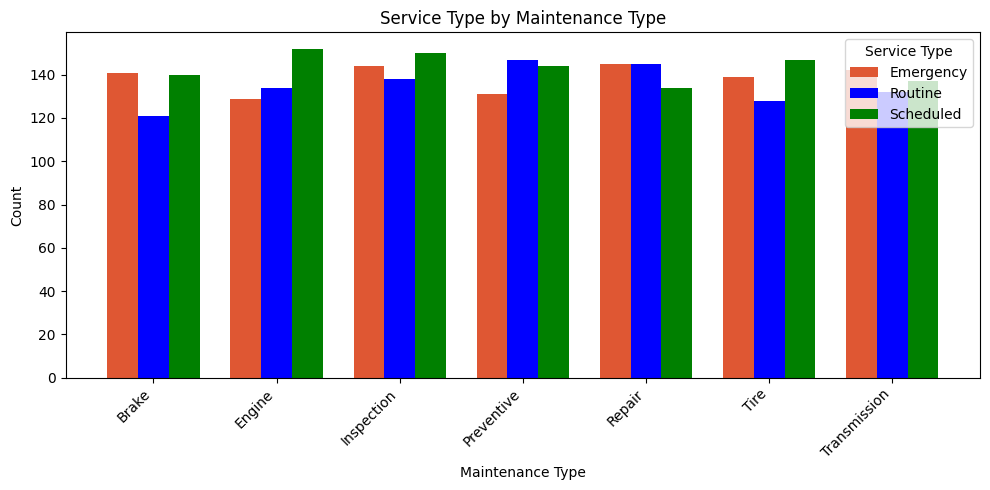

In [ ]:
counts = pd.crosstab(df['maintenance_type'], df['service_detail'])

x = np.arange(len(counts.index))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

color_map = {
    'Emergency': '#DF5733',
    'Routine': 'blue',
    'Scheduled': 'green'
}

for i, stype in enumerate(counts.columns):
    ax.bar(
        x + (i - (len(counts.columns) - 1) / 2) * w,
        counts[stype].values,
        width=w,
        label=stype,
        color=color_map.get(stype, 'gray')
    )

ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
ax.set_xlabel('Maintenance Type')
ax.set_ylabel('Count')
ax.set_title('Service Type by Maintenance Type')
ax.legend(title='Service Type')

plt.tight_layout()
plt.show()


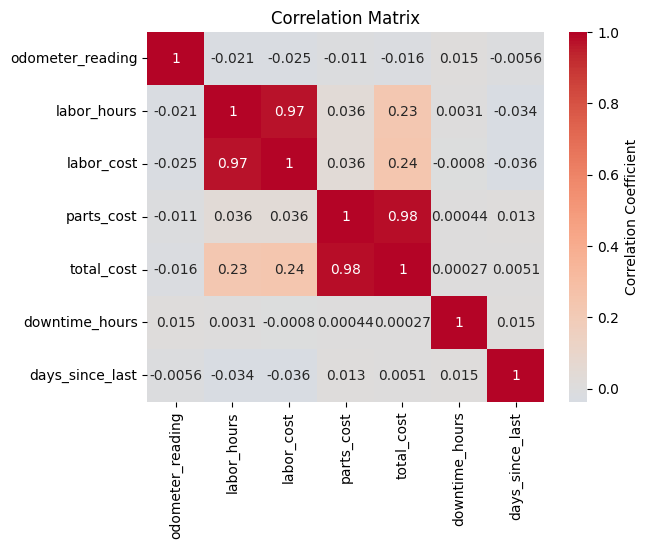

In [ ]:
# feature correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix')
# plt.tight_layout()
plt.show()


# Encoding

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
df_encoded = encoder.fit_transform(df[maintenance_information])
numerical_cols = [
    'odometer_reading', 'labor_hours', 'labor_cost', 'parts_cost',
    'total_cost', 'downtime_hours', 'days_since_last'
]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), maintenance_information)
])

# Training

In [ ]:
preprocessor.fit(df[numerical_cols + maintenance_information])

models = {}    
df['anomaly_score'] = 0.0
df['is_anomaly'] = False

for mtype in df['maintenance_type'].unique():
    mask = df['maintenance_type'] == mtype
    subset = df[mask][numerical_cols + maintenance_information]
    
    X = preprocessor.transform(subset)
    
    model =IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    model.fit(X)
    models[mtype] = model

    #preds
    scores = model.decision_function(X)
    preds= model.predict(X)
    
    df.loc[mask, 'anomaly_score'] = scores
    df.loc[mask, 'is_anomaly'] = preds == -1

In [ ]:
# Inspect results
print(df['is_anomaly'].value_counts())
print("\n--- Flagged Anomalies ---")
display(df[df['is_anomaly']][['truck_id', 'maintenance_date', 'maintenance_type',
                             'total_cost', 'odometer_reading', 'days_since_last',
                             'anomaly_score']].sort_values('anomaly_score').head(20))

is_anomaly
False    2770
True      150
Name: count, dtype: int64

--- Flagged Anomalies ---


,truck_id,maintenance_date,maintenance_type,total_cost,odometer_reading,days_since_last,anomaly_score
maintenance_id,,,,,,,
MAINT00002384,TRK00024,2024-06-09,Transmission,2185.97,742845,347.0,-0.049553
MAINT00001167,TRK00002,2023-03-09,Inspection,195.37,502652,228.0,-0.043465
MAINT00000424,TRK00098,2022-06-04,Repair,4240.05,61783,31.0,-0.042803
MAINT00001119,TRK00075,2023-02-18,Transmission,4362.88,532630,123.0,-0.041572
MAINT00002387,TRK00068,2024-06-10,Repair,1355.98,578291,137.0,-0.034923
MAINT00000832,TRK00059,2022-10-31,Preventive,3594.09,443475,264.0,-0.034472
MAINT00001958,TRK00015,2023-12-16,Engine,345.16,700035,198.0,-0.033556
MAINT00000779,TRK00017,2022-10-15,Tire,2552.07,158129,202.0,-0.033143
MAINT00001979,TRK00045,2023-12-25,Repair,738.63,619235,269.0,-0.032695


# Export

## Model Dump PKL

In [ ]:
joblib.dump(preprocessor, 'models/preprocessor.joblib')
joblib.dump(models, 'isolation_forest_models.joblib')

['isolation_forest_models.joblib']

## JSON

In [ ]:
# records = df.to_json(orient='table')
df.to_json('maintenance_records.json', orient='records')

## Excel

In [1]:
df_anomalies = df[df['is_anomaly']]
df_anomalies.to_excel('./anomalies.xlsx', index=False)


NameError: name 'df' is not defined

# Analysis

In [ ]:
display(df.groupby('truck_id').mean(numeric_only=True))

,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,downtime_hours
truck_id,,,,,,
TRK00001,425846.375000,4.166667,424.646250,1732.686667,2157.332917,29.716667
TRK00002,470345.703704,4.666667,487.625556,1544.561111,2032.186667,24.640741
TRK00003,372347.853659,4.297561,453.364390,1745.694634,2199.059024,27.636585
TRK00004,414847.500000,3.550000,349.873636,1402.936364,1752.810000,21.963636
TRK00005,405149.939394,4.660606,497.151515,1505.528788,2002.680303,22.745455
...,...,...,...,...,...,...
TRK00116,373951.777778,3.933333,411.699444,1795.902778,2207.602222,20.344444
TRK00117,408857.933333,3.133333,320.269333,1384.999333,1705.268667,18.066667
TRK00118,393415.514286,4.405714,451.872286,1576.864000,2028.736286,26.208571


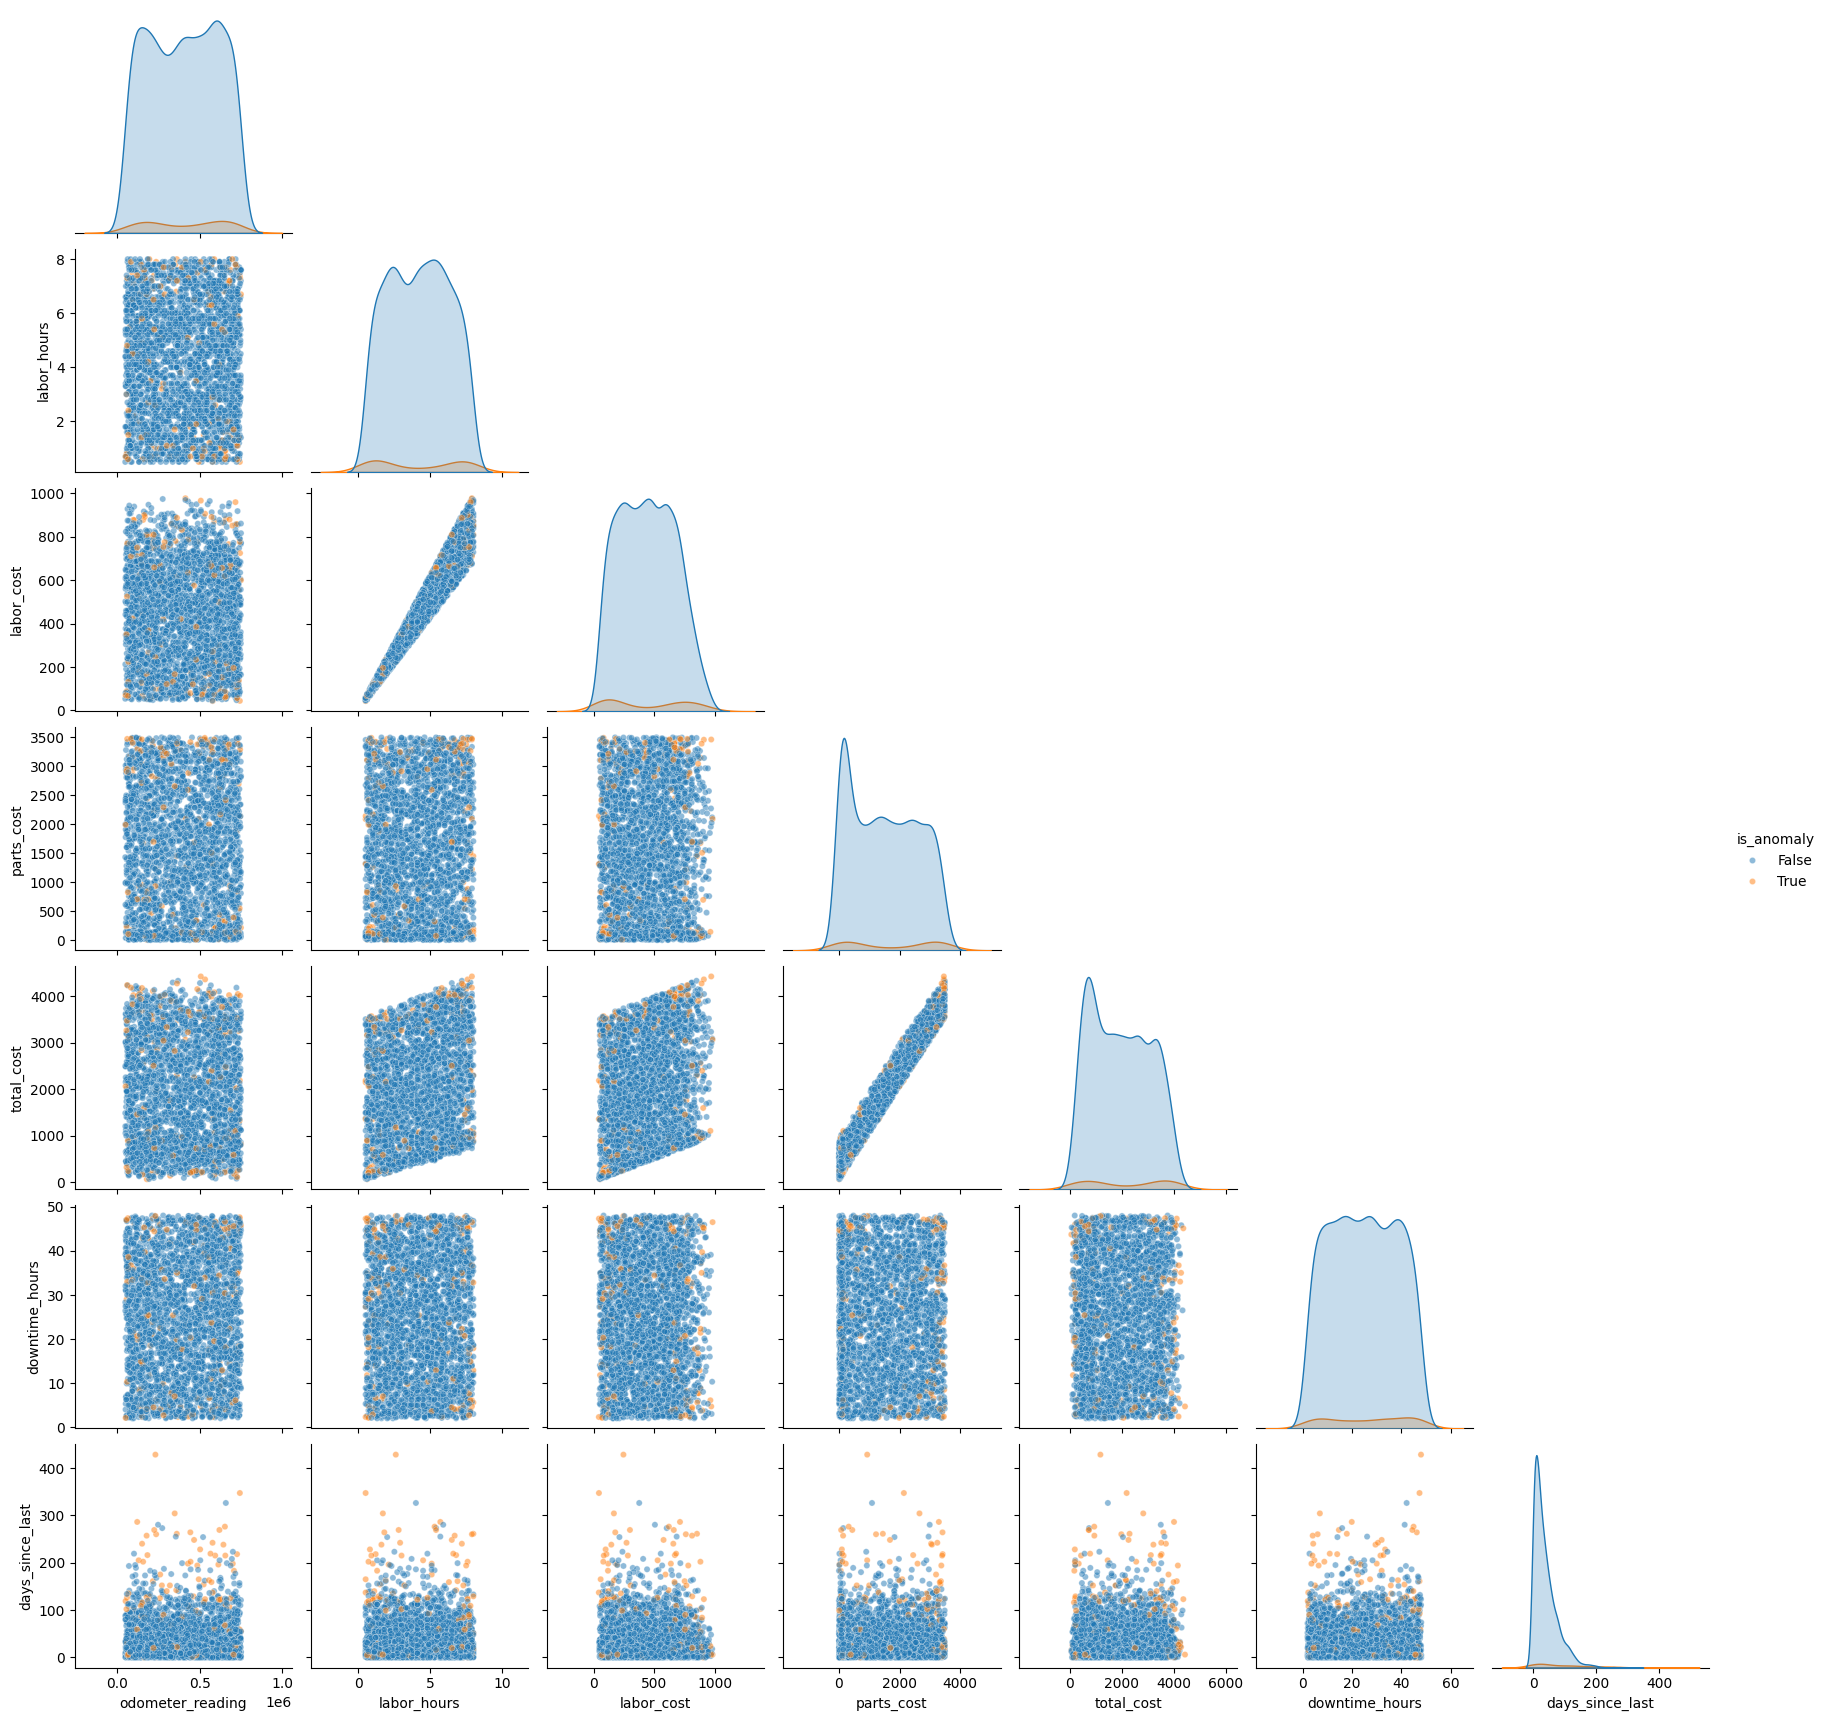

In [122]:
sns.pairplot(
    data=df[numerical_cols + ['is_anomaly']],
    vars=numerical_cols,
    hue='is_anomaly',
    corner=True,
    plot_kws={'alpha': 0.5, 's': 20}
)
plt.show()



In [128]:
# Calculate median per maintenance_type as the baseline
group_stats = df.groupby('maintenance_type')[numerical_cols].median()

# For each flagged row, show how far it deviates from its group median
flagged = df[df['is_anomaly']].copy()

for col in numerical_cols:
    flagged[f'{col}_median'] = flagged['maintenance_type'].map(group_stats[col])
    flagged[f'{col}_deviation'] = ((flagged[col] - flagged[f'{col}_median']) / flagged[f'{col}_median'] * 100).round(1)

# Show only the deviation columns so it's readable
deviation_cols = ['truck_id', 'maintenance_type', 'anomaly_score'] + [f'{col}_deviation' for col in numerical_cols]

display(flagged[deviation_cols].sort_values('anomaly_score').head(20))

,truck_id,maintenance_type,anomaly_score,odometer_reading_deviation,labor_hours_deviation,labor_cost_deviation,parts_cost_deviation,total_cost_deviation,downtime_hours_deviation,days_since_last_deviation
maintenance_id,,,,,,,,,,
MAINT00002384,TRK00024,Transmission,-0.049553,83.6,-87.5,-89.3,26.6,4.6,96.3,1288.0
MAINT00001167,TRK00002,Inspection,-0.043465,21.9,-80.0,-76.3,14.5,-60.0,38.0,812.0
MAINT00000424,TRK00098,Repair,-0.042803,-85.5,73.8,81.0,88.1,88.8,33.6,19.2
MAINT00001119,TRK00075,Transmission,-0.041572,31.7,90.0,120.9,104.4,108.9,87.1,392.0
MAINT00002387,TRK00068,Repair,-0.034923,35.6,-88.1,-89.8,-28.9,-39.6,-90.7,426.9
MAINT00000832,TRK00059,Preventive,-0.034472,4.9,-58.1,-60.1,79.2,55.7,82.6,765.6
MAINT00001958,TRK00015,Engine,-0.033556,71.7,-76.7,-73.2,-86.4,-84.0,18.6,582.8
MAINT00000779,TRK00017,Tire,-0.033143,-57.9,72.7,93.7,-2.7,17.5,-65.0,621.4
MAINT00001979,TRK00045,Repair,-0.032695,45.2,-33.3,-29.7,-76.2,-67.1,-40.5,934.6
